# Trenberth Full-Budget Hyperparameter Sweep

**Goal:** Train all radiation-relevant SpeedyWeather parameters toward the complete
[Trenberth et al. (2009)](https://doi.org/10.1175/2008BAMS2634.1) energy budget
(6 fluxes: OSR, SRU, SRD, OLR, LRD, LRU) and systematically identify which
optimizer hyperparameters produce stable, converging gradients.

**Problem this notebook addresses:**  
`radiation_sw.ipynb` converges well on SW-only loss with `Adam(5e-3)`, but attempts
at the full 6-flux Trenberth loss (`full_trend_birth_training/`) stall or diverge.
The hypothesis is that hyperparameter choices (LR, `batch_days`, `grad_clip`) matter
more for the multi-flux case because LW gradients have different magnitudes than SW.

## Structure
| Phase | Resolution | Purpose |
|-------|-----------|--------|
| **1 – Quick diagnostic** | T15, 20 batches | Survey 9 (LR × batch\_days) configs; find stable region |
| **2 – Full sweep** | T31, 200 batches | Train top-3 configs to near-convergence |
| **3 – Gradient analysis** | — | Per-parameter gradient magnitudes; identify dead params |

**Runtime:** Phase 1 ≈ 30–60 min · Phase 2 ≈ 2–4 h per config  
All phases are **resume-safe**: re-run a cell and it loads from disk if results exist.

In [2]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))

using SpeedyCalibration
using SpeedyWeather
using Optimisers
using CairoMakie
using Dates
using Printf
using Statistics

println("SpeedyCalibration loaded.")

  Activating project at `~/master_thesis/Code_SpeedyWeather/SpeedyCalibration.jl`
Precompiling packages...
 207831.4 ms  ✓ SpeedyCalibration
  1 dependency successfully precompiled in 209 seconds. 201 already precompiled.
[ Info: Precompiling SpeedyCalibration [5d65bc14-e915-412c-9a7c-d2e552044b02]
[ Info: Precompiling CairoMakie [13f3f980-e62b-5c42-98c6-ff1f3baf88f0]
[ Info: Precompiling ModelParametersUnitfulExt [30a72cc9-359b-520d-a5bb-2064a7c97f0f]
[ Info: Precompiling ModelParametersMakieExt [fe55f67a-76af-556c-8c6e-f9ee716b975d]
[ Info: Precompiling DomainSetsMakieExt [da481366-01c8-5b4d-b359-47a10c8532e7]
[ Info: Precompiling RingGridsMakieExt [e5dccbbd-f882-5bb0-bb40-f730cea6c903]
[ Info: Precompiling SpeedyCalibrationMakieExt [657b58ae-5d3d-567e-a598-44252c96ac46]


SpeedyCalibration loaded.


## 1  Trainable Parameters

### 1a  Shortwave parameters (11)
Identical to `radiation_sw.ipynb` — all paths are verified working.
`absorptivity_water_vapor` keeps `grad_scale=0.01f0` (≈200× stronger raw gradient).

In [3]:
param_specs_sw = [
    # ── SW cloud reflection ───────────────────────────────────────────────
    ParamSpec(:cloud_albedo,
        [:shortwave_radiation, :clouds, :cloud_albedo];
        bounds=(0.25f0, 0.95f0), initial=0.60f0),

    ParamSpec(:stratocumulus_cover_max,
        [:shortwave_radiation, :clouds, :stratocumulus_cover_max];
        bounds=(0.25f0, 0.95f0), initial=0.60f0),

    ParamSpec(:stratocumulus_albedo,
        [:shortwave_radiation, :clouds, :stratocumulus_albedo];
        bounds=(0.10f0, 0.90f0), initial=0.50f0),

    # ── SW atmospheric absorption ─────────────────────────────────────────
    ParamSpec(:absorptivity_water_vapor,
        [:shortwave_radiation, :transmissivity, :absorptivity_water_vapor];
        bounds=(60f0, 140f0), initial=75f0, grad_scale=0.01f0),

    ParamSpec(:absorptivity_dry_air,
        [:shortwave_radiation, :transmissivity, :absorptivity_dry_air];
        bounds=(0.005f0, 0.060f0), initial=0.03135f0),


    # ── Land surface albedo ───────────────────────────────────────────────
    ParamSpec(:albedo_land,
        [:albedo, :land, :albedo_land];
        bounds=(0.10f0, 0.70f0), initial=0.40f0),

    ParamSpec(:albedo_high_vegetation,
        [:albedo, :land, :albedo_high_vegetation];
        bounds=(0.04f0, 0.26f0), initial=0.15f0),

    ParamSpec(:albedo_low_vegetation,
        [:albedo, :land, :albedo_low_vegetation];
        bounds=(0.05f0, 0.35f0), initial=0.20f0),

    ParamSpec(:albedo_snow,
        [:albedo, :land, :albedo_snow];
        bounds=(0.15f0, 0.75f0), initial=0.40f0),

    # ── Ocean surface albedo ──────────────────────────────────────────────
    ParamSpec(:albedo_ocean,
        [:albedo, :ocean, :albedo_ocean];
        bounds=(0.02f0, 0.10f0), initial=0.06f0),
]

println("SW params: ", length(param_specs_sw))

SW params: 10


### 1b  Longwave parameters (5)

The paths use Julia Unicode symbols (`τ₀_equator`, `fₗ`). The verification block below
tests each path and skips any that fail — so the cell is safe to run even if
the SpeedyWeather version has renamed a field.

In [4]:
# Candidate LW params — paths verified against full_trend_birth_training notebook
_lw_candidates = [
    ParamSpec(:tau0_equator,
        [:longwave_radiation, :transmissivity, :τ₀_equator];
        bounds=(2f0, 12f0), initial=6f0),

    ParamSpec(:tau0_pole,
        [:longwave_radiation, :transmissivity, :τ₀_pole];
        bounds=(0.3f0, 4f0), initial=1.5f0),

    ParamSpec(:fl,
        [:longwave_radiation, :transmissivity, :fₗ];
        bounds=(0.0f0, 0.5f0), initial=0.1f0),

    ParamSpec(:emissivity_ocean,
        [:longwave_radiation, :radiative_transfer, :emissivity_ocean];
        bounds=(0.80f0, 1.00f0), initial=0.98f0),

    ParamSpec(:emissivity_land,
        [:longwave_radiation, :radiative_transfer, :emissivity_land];
        bounds=(0.80f0, 1.00f0), initial=0.98f0),
]

# Verify each path exists in the current SpeedyWeather version
_sg_chk = SpectralGrid(trunc=31, nlayers=8)
_m_chk  = PrimitiveWetModel(_sg_chk)

param_specs_lw = ParamSpec[]
println("LW parameter path check:")
for spec in _lw_candidates
    try
        val = foldl(getproperty, spec.path; init=_m_chk)
        push!(param_specs_lw, spec)
        @printf("  ✓ %-22s = %.4f  bounds=[%.2f, %.2f]\n",
                spec.name, val, spec.bounds...)
    catch e
        @printf("  ✗ %-22s SKIPPED: path not found (%s)\n",
                spec.name, typeof(e))
    end
end

all_param_specs = vcat(param_specs_sw, param_specs_lw)
@printf("\nTotal trainable parameters: %d (%d SW + %d LW)\n",
        length(all_param_specs), length(param_specs_sw), length(param_specs_lw))

LW parameter path check:
  ✓ tau0_equator           = 6.0000  bounds=[2.00, 12.00]
  ✓ tau0_pole              = 1.5000  bounds=[0.30, 4.00]
  ✓ fl                     = 0.1000  bounds=[0.00, 0.50]
  ✓ emissivity_ocean       = 0.9800  bounds=[0.80, 1.00]
  ✓ emissivity_land        = 0.9800  bounds=[0.80, 1.00]

Total trainable parameters: 15 (10 SW + 5 LW)


## 2  Loss Configurations

We compare two loss definitions:
- **`TRENBERTH_LOSS`** (built-in): all 6 fluxes with the default weight schedule
- **`LW_UPWEIGHTED`**: same targets but LW terms ×3 to compensate weaker gradients

The Trenberth targets (W m⁻²):

| Flux | Target | Trenberth weight | LW-upweighted weight |
|------|--------|-----------------|----------------------|
| OSR  | 101.9  | 1.0 | 1.0 |
| SRU  |  23.0  | 0.5 | 0.5 |
| SRD  | 168.0  | 0.5 | 0.5 |
| OLR  | 235.0  | 1.0 | 3.0 |
| LRD  | 333.0  | 0.3 | 1.0 |
| LRU  | 398.0  | 0.3 | 1.0 |

A third config **`loss_residual_normalized`** is built dynamically: weights are `1/residual²` at the
initial state so every flux contributes **equally** to the loss from batch 1 onward.

In [5]:
loss_trenberth = TRENBERTH_LOSS   # built-in 6-flux Trenberth loss

loss_lw_upweighted = LossConfig(
    [:osr, :sru, :srd, :olr, :lrd, :lru];
    targets = Dict(:osr => 101.9f0, :sru =>  23.0f0, :srd => 168.0f0,
                   :olr => 235.0f0, :lrd => 333.0f0, :lru => 398.0f0),
    weights = Dict(:osr => 1.0f0,   :sru =>  0.5f0,  :srd => 0.5f0,
                   :olr => 3.0f0,   :lrd =>  1.0f0,  :lru => 1.0f0),
)



# Residual-normalised loss: each flux contributes equally at initialisation.
# Weights = 1/residual² using typical default-param global means.
# Adjust `_initial_sw` / `_initial_lw` after a short diagnostic run if needed.
_initial_sw = Dict(:osr => 74.5f0, :sru => 18.3f0, :srd => 163.0f0)
_initial_lw = Dict(:olr => 258.0f0, :lrd => 295.0f0, :lru => 358.0f0)
_targets_6  = Dict(:osr => 101.9f0, :sru => 23.0f0, :srd => 168.0f0,
                   :olr => 235.0f0, :lrd => 333.0f0, :lru => 398.0f0)
loss_residual_normalized = make_normalized_loss(
    [:osr, :sru, :srd, :olr, :lrd, :lru],
    _targets_6,
    merge(_initial_sw, _initial_lw),
)

println("Loss configs defined: loss_trenberth, loss_lw_upweighted, loss_residual_normalized")

Loss configs defined: loss_trenberth, loss_lw_upweighted, loss_residual_normalized


## 3  Hyperparameter Grid

**Phase 1 axes** (quick T15 sweep):
- Learning rate: {1e-3, 5e-3, 1e-2}
- `batch_days`: {3, 10, 30} (controls gradient noise — longer = smoother but slower)
- Loss: `TRENBERTH_LOSS` (fixed, to isolate LR/batch\_days effect)

**Phase 2 selection**: pick top-3 Phase-1 configs (lowest `best_smoothed_loss`)
and add a `loss_lw_upweighted` variant of the winner for sensitivity analysis.

In [6]:
# Phase 1 grid: 3 LR x 3 batch_days = 9 configs
const LRS = [1f-3, 5f-3, 1f-2]
const BDS = [1.0, 3.0, 4.0]  # alias-safe under daily_cycle=true: steps_per_sample coprime with 36 steps/day (bd=10,30 gave exact 12h aliasing)

struct SweepConfig
    name        :: String
    label       :: String
    lr          :: Float32
    bd          :: Float64
    loss_config :: LossConfig
    color       :: Symbol
end

_palette = [:firebrick, :tomato, :coral,
            :steelblue, :dodgerblue, :deepskyblue,
            :seagreen,  :mediumseagreen, :olivedrab]

# Explicit flat list to avoid 2D matrix from Iterators.product comprehension
_grid = [(lr, bd) for lr in LRS for bd in BDS]
phase1_configs = SweepConfig[
    SweepConfig(
        @sprintf("lr%.0e_bd%02d", lr, round(Int, bd)),
        @sprintf("LR=%.0e  bd=%gd", lr, bd),
        lr, bd, loss_trenberth, _palette[i],
    )
    for (i, (lr, bd)) in enumerate(_grid)
]

println("Phase-1 sweep grid ($(length(phase1_configs)) configs):")
@printf("  %-22s  %8s  %8s\n", "name", "LR", "bd (d)")
println("  ", "-"^44)
for c in phase1_configs
    @printf("  %-22s  %8.0e  %8.1f\n", c.name, c.lr, c.bd)
end

Phase-1 sweep grid (9 configs):
  name                          LR    bd (d)
  --------------------------------------------
  lr1e-03_bd03               1e-03       3.0
  lr1e-03_bd10               1e-03      10.0
  lr1e-03_bd30               1e-03      30.0
  lr5e-03_bd03               5e-03       3.0
  lr5e-03_bd10               5e-03      10.0
  lr5e-03_bd30               5e-03      30.0
  lr1e-02_bd03               1e-02       3.0
  lr1e-02_bd10               1e-02      10.0
  lr1e-02_bd30               1e-02      30.0


## 4  Phase 1 — Quick Diagnostic Sweep (T15, 20 batches)

Each run takes ~3–6 minutes at T15. The cell is **resume-safe**:
if `result.jld2` already exists in the output folder it is loaded from disk.

> **Tip:** If a config prints *"all gradient samples invalid"* at batch 1,
> the model went NaN during spinup. This usually means `batch_days` is too long
> for the resolution, or the initial parameters are outside the stable region.
> Reduce `batch_days` or increase `spinup_days` in `_quick_cfg` below.

In [7]:
const QUICK_DIR = joinpath(@__DIR__, "output", "hp_sweep_phase1")

function _quick_cfg(sc::SweepConfig)
    TrainingConfig(
        spinup_days       = 60,
        batch_days        = sc.bd,
        samples_per_batch = 10,
        max_batches       = 20,
        loss_threshold    = 0.1f0,   # stop early only if very close — unlikely at T15
        loss_window_size  = 5,
        grad_clip         = 5f0,
        enable_lr_decay   = false,   # keep LR fixed for clean comparison
        trunc             = 15,
        nlayers           = 5,
        daily_cycle       = true,    # required: physical diurnal cycle must stay on
        warmup_enzyme     = true,
        verbose           = false,
    )
end

phase1_results = Dict{String, TrainingResult}()

for (k, sc) in enumerate(phase1_configs)
    rfile = joinpath(QUICK_DIR, sc.name, "result.jld2")
    if isfile(rfile)
        phase1_results[sc.name] = load_result(rfile)
        @printf("[%d/%d] %-22s  loaded from disk\n",
                k, length(phase1_configs), sc.name)
        continue
    end
    @printf("[%d/%d] %-22s  running...\n", k, length(phase1_configs), sc.name)
    flush(stdout)
    r = calibrate!(
        all_param_specs,
        Optimisers.Adam(sc.lr),
        sc.loss_config,
        _quick_cfg(sc);
        save_dir = joinpath(QUICK_DIR, sc.name),
    )
    phase1_results[sc.name] = r
    @printf("       done: %d batches, best loss = %.1f\n",
            r.conv_info.total_batches, r.conv_info.best_smoothed_loss)
end

println("\nPhase 1 complete.")

[1/9] lr1e-03_bd03            loaded from disk
[2/9] lr1e-03_bd10            loaded from disk
[3/9] lr1e-03_bd30            loaded from disk
[4/9] lr5e-03_bd03            loaded from disk
[5/9] lr5e-03_bd10            loaded from disk
[6/9] lr5e-03_bd30            loaded from disk
[7/9] lr1e-02_bd03            loaded from disk
[8/9] lr1e-02_bd10            loaded from disk
[9/9] lr1e-02_bd30            loaded from disk

Phase 1 complete.


In [8]:
println("\nPhase-1 Summary")
@printf("%-24s  %6s  %6s  %8s  %8s  %6s\n",
        "Config", "LR", "bd(d)", "Best L", "Final L", "Batches")
println("-" ^ 68)

for sc in phase1_configs
    r = get(phase1_results, sc.name, nothing)
    isnothing(r) && continue
    nb   = r.conv_info.total_batches
    best = r.conv_info.best_smoothed_loss
    final = length(r.history[:smoothed_loss]) >= nb ? r.history[:smoothed_loss][nb] : NaN32
    @printf("%-24s  %6.0e  %6.1f  %8.1f  %8.1f  %6d\n",
            sc.label, sc.lr, sc.bd, best, final, nb)
end

# Sort by best loss (phase1_configs is a Vector, but sort explicitly with by= keyword)
sorted = sort(phase1_configs;
    by = sc -> get(phase1_results, sc.name, nothing) === nothing ? Inf :
               phase1_results[sc.name].conv_info.best_smoothed_loss)
println("\nTop-3 recommended for Phase-2 (full T31 sweep):")
for (i, sc) in enumerate(sorted[1:min(3, end)])
    r = phase1_results[sc.name]
    @printf("  %d. %s  (best=%.1f)\n", i, sc.label,
            r.conv_info.best_smoothed_loss)
end


Phase-1 Summary
Config                        LR   bd(d)    Best L   Final L  Batches
--------------------------------------------------------------------
LR=1e-03  bd=3d            1e-03     3.0    1818.8    1818.8      20
LR=1e-03  bd=10d           1e-03    10.0    1208.1    1208.1      20
LR=1e-03  bd=30d           1e-03    30.0    1359.8    1692.2      20
LR=5e-03  bd=3d            5e-03     3.0    1652.8    1652.8      20
LR=5e-03  bd=10d           5e-03    10.0    1104.5    1104.5      20
LR=5e-03  bd=30d           5e-03    30.0    1312.0    2389.8      20
LR=1e-02  bd=3d            1e-02     3.0    1464.6    1464.6      20
LR=1e-02  bd=10d           1e-02    10.0    1026.3    1026.3      20
LR=1e-02  bd=30d           1e-02    30.0    1114.6    2354.7      20

Top-3 recommended for Phase-2 (full T31 sweep):
  1. LR=1e-02  bd=10d  (best=1026.3)
  2. LR=5e-03  bd=10d  (best=1104.5)
  3. LR=1e-02  bd=30d  (best=1114.6)


### Phase-1 Visualisation

Three panels:
1. **Loss curves by LR** (fixed `bd=3d`) — shows sensitivity to learning rate
2. **Loss curves by batch_days** (fixed `LR=5e-3`) — shows sensitivity to gradient noise
3. **Heatmap** — best smoothed loss for all 9 configs

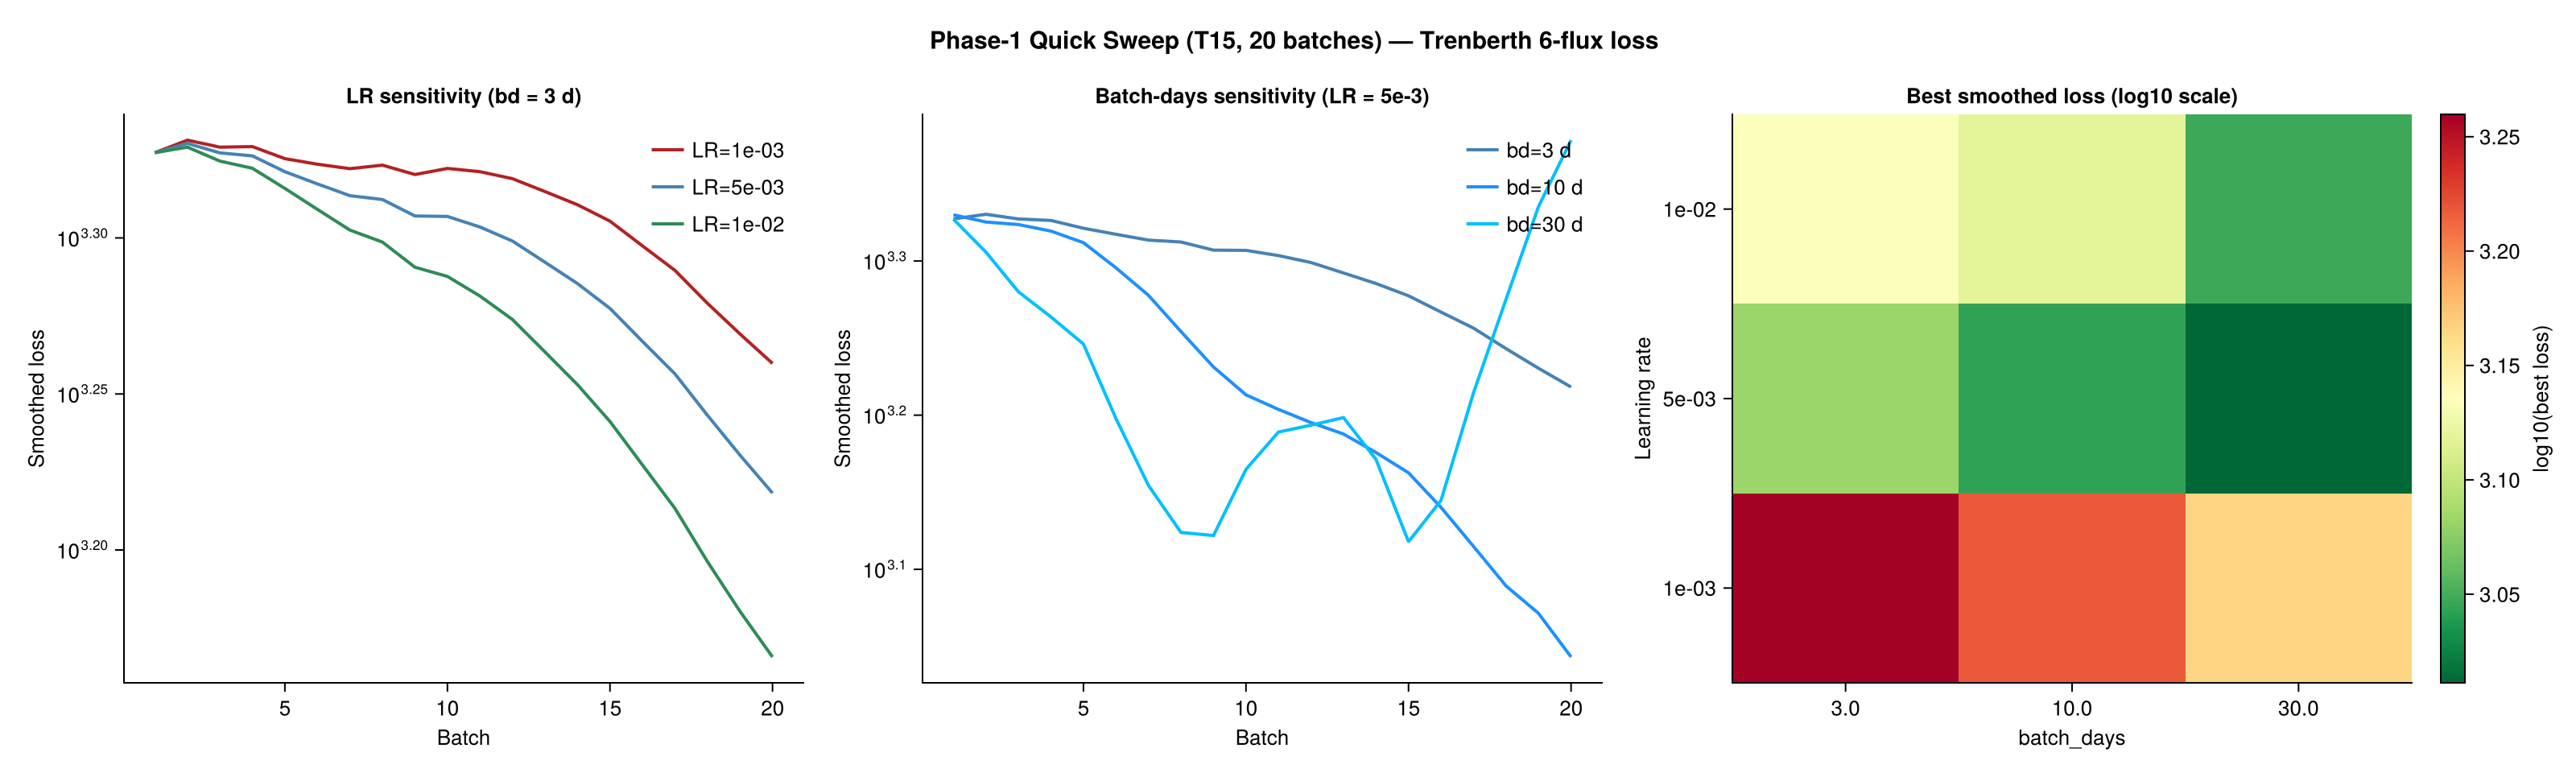

In [9]:
_ax = (xgridvisible=false, ygridvisible=false,
       topspinevisible=false, rightspinevisible=false)

fig_p1 = Figure(size=(1600, 480), fontsize=13)

# Panel 1: vary LR, fix bd=3
ax1 = Axis(fig_p1[1,1]; title="LR sensitivity (bd = 3 d)",
           xlabel="Batch", ylabel="Smoothed loss",
           yscale=log10, _ax...)
for sc in filter(c -> c.bd ≈ 3.0, phase1_configs)
    r = get(phase1_results, sc.name, nothing); isnothing(r) && continue
    nb = r.conv_info.total_batches
    l  = r.history[:smoothed_loss][1:nb]
    lines!(ax1, 1:nb, l; label=@sprintf("LR=%.0e", sc.lr),
           color=sc.color, linewidth=2)
end
axislegend(ax1; position=:rt, framevisible=false)

# Panel 2: vary bd, fix LR=5e-3
ax2 = Axis(fig_p1[1,2]; title="Batch-days sensitivity (LR = 5e-3)",
           xlabel="Batch", ylabel="Smoothed loss",
           yscale=log10, _ax...)
for sc in filter(c -> c.lr ≈ 5f-3, phase1_configs)
    r = get(phase1_results, sc.name, nothing); isnothing(r) && continue
    nb = r.conv_info.total_batches
    l  = r.history[:smoothed_loss][1:nb]
    lines!(ax2, 1:nb, l; label=@sprintf("bd=%.0f d", sc.bd),
           color=sc.color, linewidth=2)
end
axislegend(ax2; position=:rt, framevisible=false)

# Panel 3: heatmap of best loss
ax3 = Axis(fig_p1[1,3];
           title="Best smoothed loss (log10 scale)",
           xlabel="batch_days",
           ylabel="Learning rate",
           xticks = (1:3, string.(BDS)),
           yticks = (1:3, [@sprintf("%.0e", lr) for lr in LRS]),
           _ax...)

_loss_mat = Float32[
    let nm = @sprintf("lr%.0e_bd%02d", lr, round(Int,bd))
        haskey(phase1_results, nm) ?
            log10(max(phase1_results[nm].conv_info.best_smoothed_loss, 0.01f0)) : NaN32
    end
    for lr in LRS, bd in BDS
]
hm = heatmap!(ax3, 1:3, 1:3, _loss_mat; colormap=cgrad(:RdYlGn, rev=true))
Colorbar(fig_p1[1,4], hm; label="log10(best loss)", width=15)

Label(fig_p1[0,:],
    "Phase-1 Quick Sweep (T15, 20 batches) — Trenberth 6-flux loss",
    fontsize=15, font=:bold)

save(joinpath(QUICK_DIR, "phase1_comparison.pdf"), fig_p1)
fig_p1

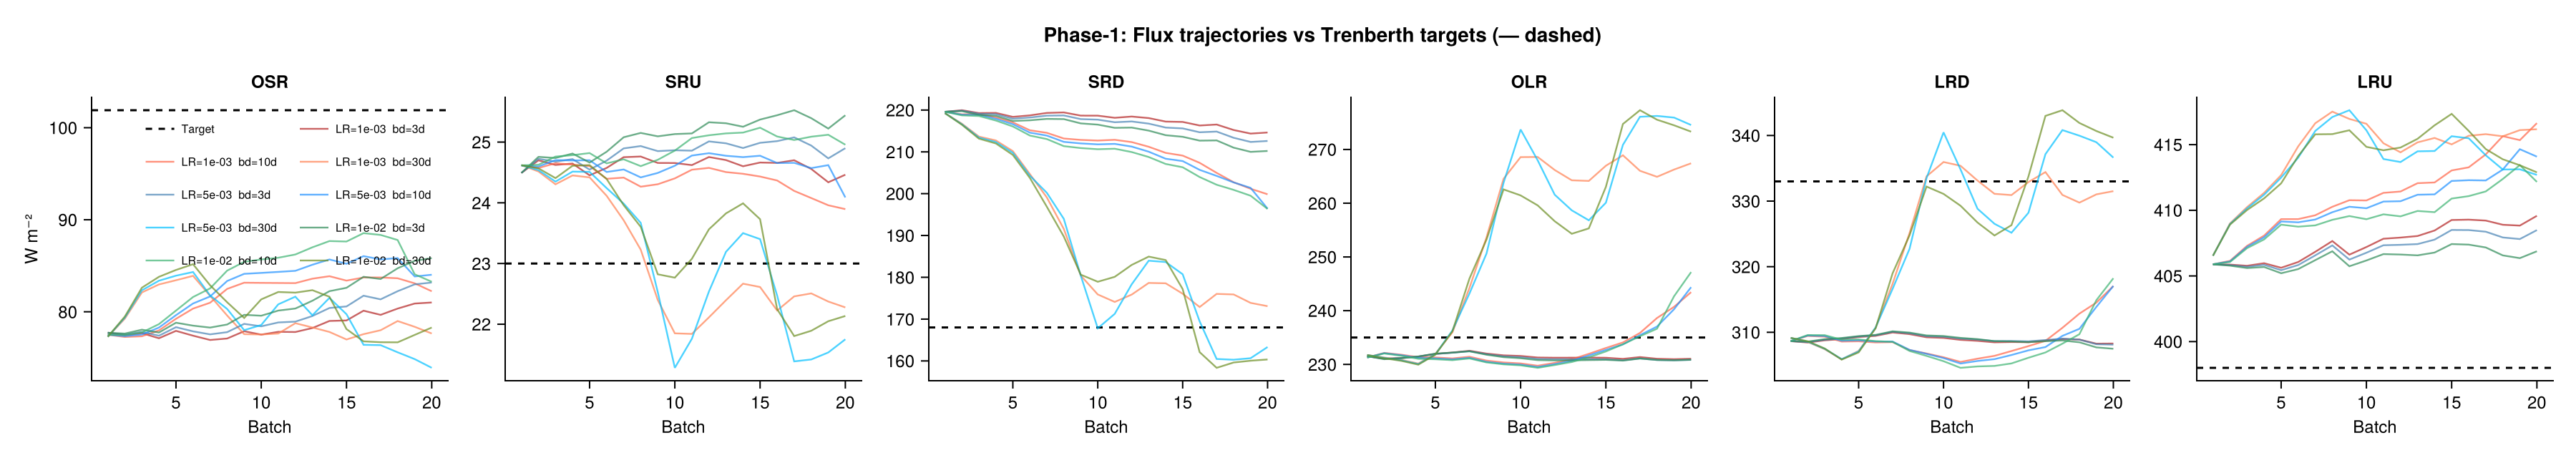

In [10]:
# Per-flux mean at end of each run vs Trenberth targets
const TRENBERTH_TARGETS = Dict(
    :osr => 101.9f0, :sru => 23.0f0, :srd => 168.0f0,
    :olr => 235.0f0, :lrd => 333.0f0, :lru => 398.0f0,
)

fig_flux_p1 = Figure(size=(1800, 320), fontsize=12)
_flux_keys  = [:osr, :sru, :srd, :olr, :lrd, :lru]
_flux_label = Dict(:osr=>"OSR", :sru=>"SRU", :srd=>"SRD",
                   :olr=>"OLR", :lrd=>"LRD", :lru=>"LRU")

for (col, fk) in enumerate(_flux_keys)
    ax = Axis(fig_flux_p1[1, col];
              title  = _flux_label[fk],
              xlabel = "Batch",
              ylabel = col == 1 ? "W m⁻²" : "",
              _ax...)
    hlines!(ax, [TRENBERTH_TARGETS[fk]]; color=:black, linestyle=:dash,
            linewidth=1.5, label="Target")
    for sc in phase1_configs
        r = get(phase1_results, sc.name, nothing)
        isnothing(r) || !haskey(r.history, fk) && continue
        nb  = r.conv_info.total_batches
        val = r.history[fk][1:nb]
        isempty(val) && continue
        lines!(ax, 1:length(val), val;
               color=(sc.color, 0.7), linewidth=1.2, label=sc.label)
    end
    col == 1 && axislegend(ax; position=:rt, framevisible=false,
                           labelsize=8, nbanks=2)
end

Label(fig_flux_p1[0,:],
    "Phase-1: Flux trajectories vs Trenberth targets (— dashed)",
    fontsize=14, font=:bold)

save(joinpath(QUICK_DIR, "phase1_fluxes.pdf"), fig_flux_p1)
fig_flux_p1

## 5  Phase 2 — Full T31 Sweep

Run the top-3 Phase-1 configs at full T31 resolution (200 batches each).
Plus one additional variant to test loss-weight sensitivity:
- **`lw_upweighted`**: winner config with `loss_lw_upweighted` (OLR/LRD/LRU ×3)

**Edit `PHASE2_NAMES` below** to pick which Phase-1 configs to promote.
The cell reads the Phase-1 summary and auto-selects top-3 if you leave the list empty.

In [11]:
# ── Select Phase-2 configs ────────────────────────────────────────────────
# Leave empty to auto-select top-3 from Phase-1, or specify names explicitly:
PHASE2_NAMES = String[]  # e.g. ["lr5e-03_bd03", "lr1e-02_bd03", "lr5e-03_bd10"]

if isempty(PHASE2_NAMES)
    _ranked = sort(phase1_configs;
        by = sc -> haskey(phase1_results, sc.name) ?
                   phase1_results[sc.name].conv_info.best_smoothed_loss : Inf)
    PHASE2_NAMES = [sc.name for sc in _ranked[1:min(3, end)]]
    println("Auto-selected Phase-2 configs: ", PHASE2_NAMES)
end

# Build Phase-2 run list (selected configs + LW-upweighted variant of winner)
struct Phase2Run
    name        :: String
    label       :: String
    base_config :: SweepConfig
    loss_config :: LossConfig
    color       :: Symbol
end

_colors2 = [:steelblue, :firebrick, :seagreen, :darkorange]

phase2_runs = Phase2Run[
    Phase2Run(
        "full_" * sc.name,
        sc.label * " [T₈ loss]",
        sc,
        loss_trenberth,
        _colors2[i],
    )
    for (i, sc) in enumerate(filter(c -> c.name in PHASE2_NAMES, phase1_configs))
]

# Add LW-upweighted variant of the first (best) config
if !isempty(phase2_runs)
    winner = phase2_runs[1].base_config
    push!(phase2_runs, Phase2Run(
        "full_" * winner.name * "_lwup",
        winner.label * " [LW×3]",
        winner,
        loss_lw_upweighted,
        _colors2[end],
    ))
end

println("Phase-2 runs ($(length(phase2_runs)):")
for r in phase2_runs
    println("  ", r.name, "  (", r.label, ")")
end

Auto-selected Phase-2 configs: ["lr1e-02_bd10", "lr5e-03_bd10", "lr1e-02_bd30"]
Phase-2 runs (4:
  full_lr5e-03_bd10  (LR=5e-03  bd=10d [T₈ loss])
  full_lr1e-02_bd10  (LR=1e-02  bd=10d [T₈ loss])
  full_lr1e-02_bd30  (LR=1e-02  bd=30d [T₈ loss])
  full_lr5e-03_bd10_lwup  (LR=5e-03  bd=10d [LW×3])


In [12]:
const FULL_DIR = joinpath(@__DIR__, "output", "hp_sweep_phase2")

# batch_days inherited from Phase-1 winner (p2r.base_config.bd).
# NOTE: with daily_cycle=true, steps_per_day=36 (Delta t=40min at trunc=31). bd=10/30 give
# steps_per_sample=18/54 (both === 18 mod 36 = exactly 12h) -> hard aliasing, only 2 diurnal
# phases ever sampled. Only use bd values whose steps_per_sample is coprime-ish with 36
# (see BDS grid above). LR decay loosened: patience=80, max 2 decays.
function _full_cfg(p2r::Phase2Run)
    TrainingConfig(
        spinup_days         = 180,
        batch_days          = p2r.base_config.bd,
        samples_per_batch   = 20,
        max_batches         = 300,
        loss_threshold      = 5f0,
        loss_window_size    = 20,
        grad_clip           = 5f0,
        enable_lr_decay     = true,
        lr_decay_factor     = 0.5f0,
        lr_plateau_patience = 80,
        min_lr              = 1f-5,
        max_lr_decays       = 2,
        trunc               = 31,
        nlayers             = 8,
        daily_cycle         = true,   # required: physical diurnal cycle must stay on
        warmup_enzyme       = true,
        verbose             = true,
    )
end

phase2_results = Dict{String, TrainingResult}()

# ── SW-only baseline (run first — proves T31 gradients work before adding LW) ─
let
    name = "sw_baseline"
    rfile = joinpath(FULL_DIR, name, "result.jld2")
    if isfile(rfile)
        phase2_results[name] = load_result(rfile)
        println("sw_baseline  →  loaded from disk")
    else
        println("\nsw_baseline  →  starting (SW params + OSR/SRU/SRD loss)")
        r = calibrate!(
            param_specs_sw,
            Optimisers.Adam(5f-3),
            OSR_SRU_SRD_LOSS,
            TrainingConfig(
                spinup_days=180, batch_days=3.0, samples_per_batch=20,
                max_batches=300, loss_threshold=50f0, loss_window_size=20,
                grad_clip=5f0, enable_lr_decay=true, lr_decay_factor=0.5f0,
                lr_plateau_patience=50, min_lr=1f-5, max_lr_decays=3,
                trunc=31, nlayers=8, daily_cycle=false, verbose=true,
            );
            save_dir = joinpath(FULL_DIR, name),
        )
        phase2_results[name] = r
        @printf("       done: %d batches, best_loss=%.1f, %s\n",
                r.conv_info.total_batches, r.conv_info.best_smoothed_loss,
                r.conv_info.stop_reason)
    end
end

# ── Full Trenberth runs (top Phase-1 configs) ─────────────────────────────────
for (k, p2r) in enumerate(phase2_runs)
    rfile = joinpath(FULL_DIR, p2r.name, "result.jld2")
    if isfile(rfile)
        phase2_results[p2r.name] = load_result(rfile)
        @printf("[%d/%d] %s  →  loaded from disk\n", k, length(phase2_runs), p2r.name)
        continue
    end
    @printf("\n[%d/%d] %s  →  starting (T31, up to 300 batches)\n",
            k, length(phase2_runs), p2r.name)
    r = calibrate!(
        all_param_specs,
        Optimisers.Adam(p2r.base_config.lr),
        p2r.loss_config,
        _full_cfg(p2r);
        save_dir = joinpath(FULL_DIR, p2r.name),
    )
    phase2_results[p2r.name] = r
    @printf("       done: %d batches, best_loss=%.2f, %s\n",
            r.conv_info.total_batches,
            r.conv_info.best_smoothed_loss,
            r.conv_info.stop_reason)
end

println("\nPhase 2 complete.")

sw_baseline  →  loaded from disk
[1/4] full_lr5e-03_bd10  →  loaded from disk
[2/4] full_lr1e-02_bd10  →  loaded from disk
[3/4] full_lr1e-02_bd30  →  loaded from disk
[4/4] full_lr5e-03_bd10_lwup  →  loaded from disk

Phase 2 complete.


### Phase-2 Comparison Plots

Plots saved for full_lr5e-03_bd10
Plots saved for full_lr1e-02_bd10
Plots saved for full_lr1e-02_bd30
Plots saved for full_lr5e-03_bd10_lwup


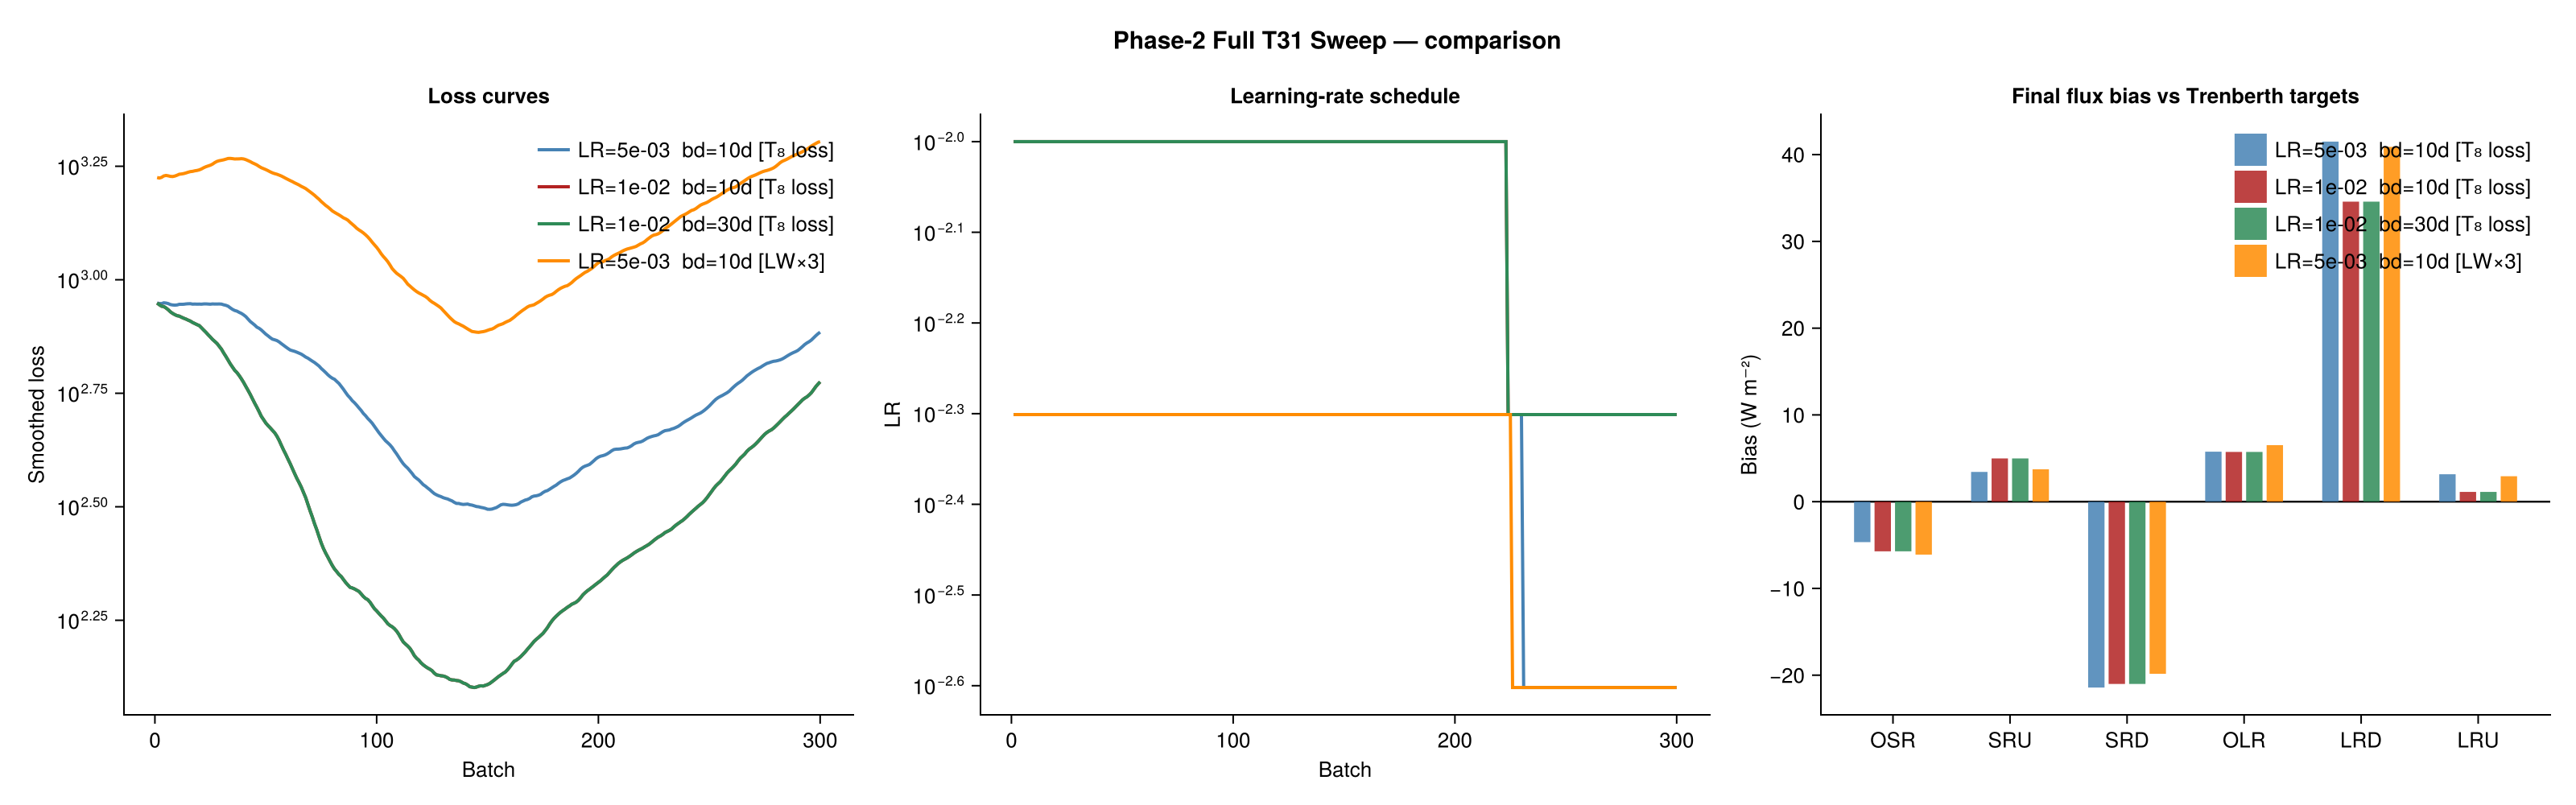

In [13]:
# Use built-in plot_training for each run's detail
for p2r in phase2_runs
    r = get(phase2_results, p2r.name, nothing)
    isnothing(r) && continue
    dir = joinpath(FULL_DIR, p2r.name)
    figs = plot_training(r; save_dir=dir)
    @printf("Plots saved for %s\n", p2r.name)
end

# Overlay loss curves across all Phase-2 runs
fig_p2 = Figure(size=(1600, 500), fontsize=13)

ax_loss = Axis(fig_p2[1,1];
    title="Loss curves", xlabel="Batch", ylabel="Smoothed loss",
    yscale=log10, _ax...)

ax_lr = Axis(fig_p2[1,2];
    title="Learning-rate schedule", xlabel="Batch", ylabel="LR",
    yscale=log10, _ax...)

for p2r in phase2_runs
    r = get(phase2_results, p2r.name, nothing)
    isnothing(r) && continue
    nb = r.conv_info.total_batches
    lines!(ax_loss, 1:nb, r.history[:smoothed_loss][1:nb];
           label=p2r.label, color=p2r.color, linewidth=2)
    lines!(ax_lr,   1:nb, r.history[:lr][1:nb];
           label=p2r.label, color=p2r.color, linewidth=2)
end
axislegend(ax_loss; position=:rt, framevisible=false)

# Per-flux final bias
ax_bias = Axis(fig_p2[1,3];
    title="Final flux bias vs Trenberth targets",
    xlabel="", ylabel="Bias (W m⁻²)",
    xticks=(1:6, uppercase.(string.(_flux_keys))),
    _ax...)
hlines!(ax_bias, [0f0]; color=:black, linewidth=1.2)

_nruns2 = length(phase2_runs)
_bw2    = 0.7f0 / _nruns2
for (k, p2r) in enumerate(phase2_runs)
    r = get(phase2_results, p2r.name, nothing)
    isnothing(r) && continue
    nb = r.conv_info.total_batches
    biases = Float32[
        haskey(r.history, fk) && length(r.history[fk]) >= nb ?
            r.history[fk][nb] - TRENBERTH_TARGETS[fk] : NaN32
        for fk in _flux_keys
    ]
    xs = collect(1:6) .+ (k - (_nruns2+1)/2f0) * _bw2
    barplot!(ax_bias, xs, biases;
             width=_bw2, color=(p2r.color, 0.85), label=p2r.label)
end
axislegend(ax_bias; position=:rt, framevisible=false)

Label(fig_p2[0,:],
      "Phase-2 Full T31 Sweep — comparison",
      fontsize=15, font=:bold)

save(joinpath(FULL_DIR, "phase2_comparison.pdf"), fig_p2)
fig_p2

## 6  Gradient-Magnitude Analysis

Which parameters actually received gradient signal?
The `|grad|` column is the mean absolute gradient over all batches;
`std` is the inter-batch standard deviation.

Parameters with `|grad| ≈ 0` are effectively not trainable with the current
loss/architecture — candidates for `grad_scale` adjustment or exclusion.

In [14]:
println("\nGradient-magnitude summary (best Phase-2 run)")

# Pick best result (lowest best_smoothed_loss)
_best_p2 = argmin(
    p2r -> haskey(phase2_results, p2r.name) ?
           phase2_results[p2r.name].conv_info.best_smoothed_loss : Inf,
    phase2_runs)
r_best = phase2_results[_best_p2.name]
nb = r_best.conv_info.total_batches

@printf("\nUsing: %s  (%d batches)\n", _best_p2.label, nb)
@printf("%-28s  %10s  %10s  %10s\n", "Parameter", "|grad| mean", "|grad| std", "param Δ")
println("-"^65)

for spec in all_param_specs
    gk  = Symbol("grad_",    spec.name)
    gsk = Symbol("gradstd_", spec.name)
    pv  = r_best.history[spec.name]
    gv  = get(r_best.history, gk,  Float32[])
    gsv = get(r_best.history, gsk, Float32[])
    isempty(gv) && continue
    g_mean = mean(abs.(gv[1:nb]))
    g_std  = isempty(gsv) ? NaN32 : mean(gsv[1:nb])
    p_init = isnothing(spec.initial) ? NaN32 : spec.initial
    p_final = length(pv) >= nb ? pv[nb] : NaN32
    @printf("%-28s  %10.4e  %10.4e  %+10.4f\n",
            spec.name, g_mean, g_std, p_final - p_init)
end


Gradient-magnitude summary (best Phase-2 run)

Using: LR=1e-02  bd=10d [T₈ loss]  (300 batches)
Parameter                     |grad| mean  |grad| std     param Δ
-----------------------------------------------------------------
cloud_albedo                  1.4985e+02  7.0216e+01     +0.1653
stratocumulus_cover_max       1.8704e+00  1.1731e+00     -0.0691
stratocumulus_albedo          2.2407e+00  1.2248e+00     -0.0735
absorptivity_water_vapor      3.1806e-01  2.2577e-01    -13.6254
absorptivity_dry_air          1.4204e+01  3.7610e+01     -0.0240
albedo_land                   1.8887e+01  7.5851e+00     +0.1815
albedo_high_vegetation        3.3387e+00  4.0737e+00     +0.0608
albedo_low_vegetation         6.4600e+00  5.9919e+00     +0.0834
albedo_snow                   3.2433e+00  1.9309e+00     +0.2375
albedo_ocean                  1.2836e+01  3.9672e+01     +0.0182
tau0_equator                  1.1528e+02  8.8896e-01     +1.3404
tau0_pole                     5.2907e+01  7.7873e-01    

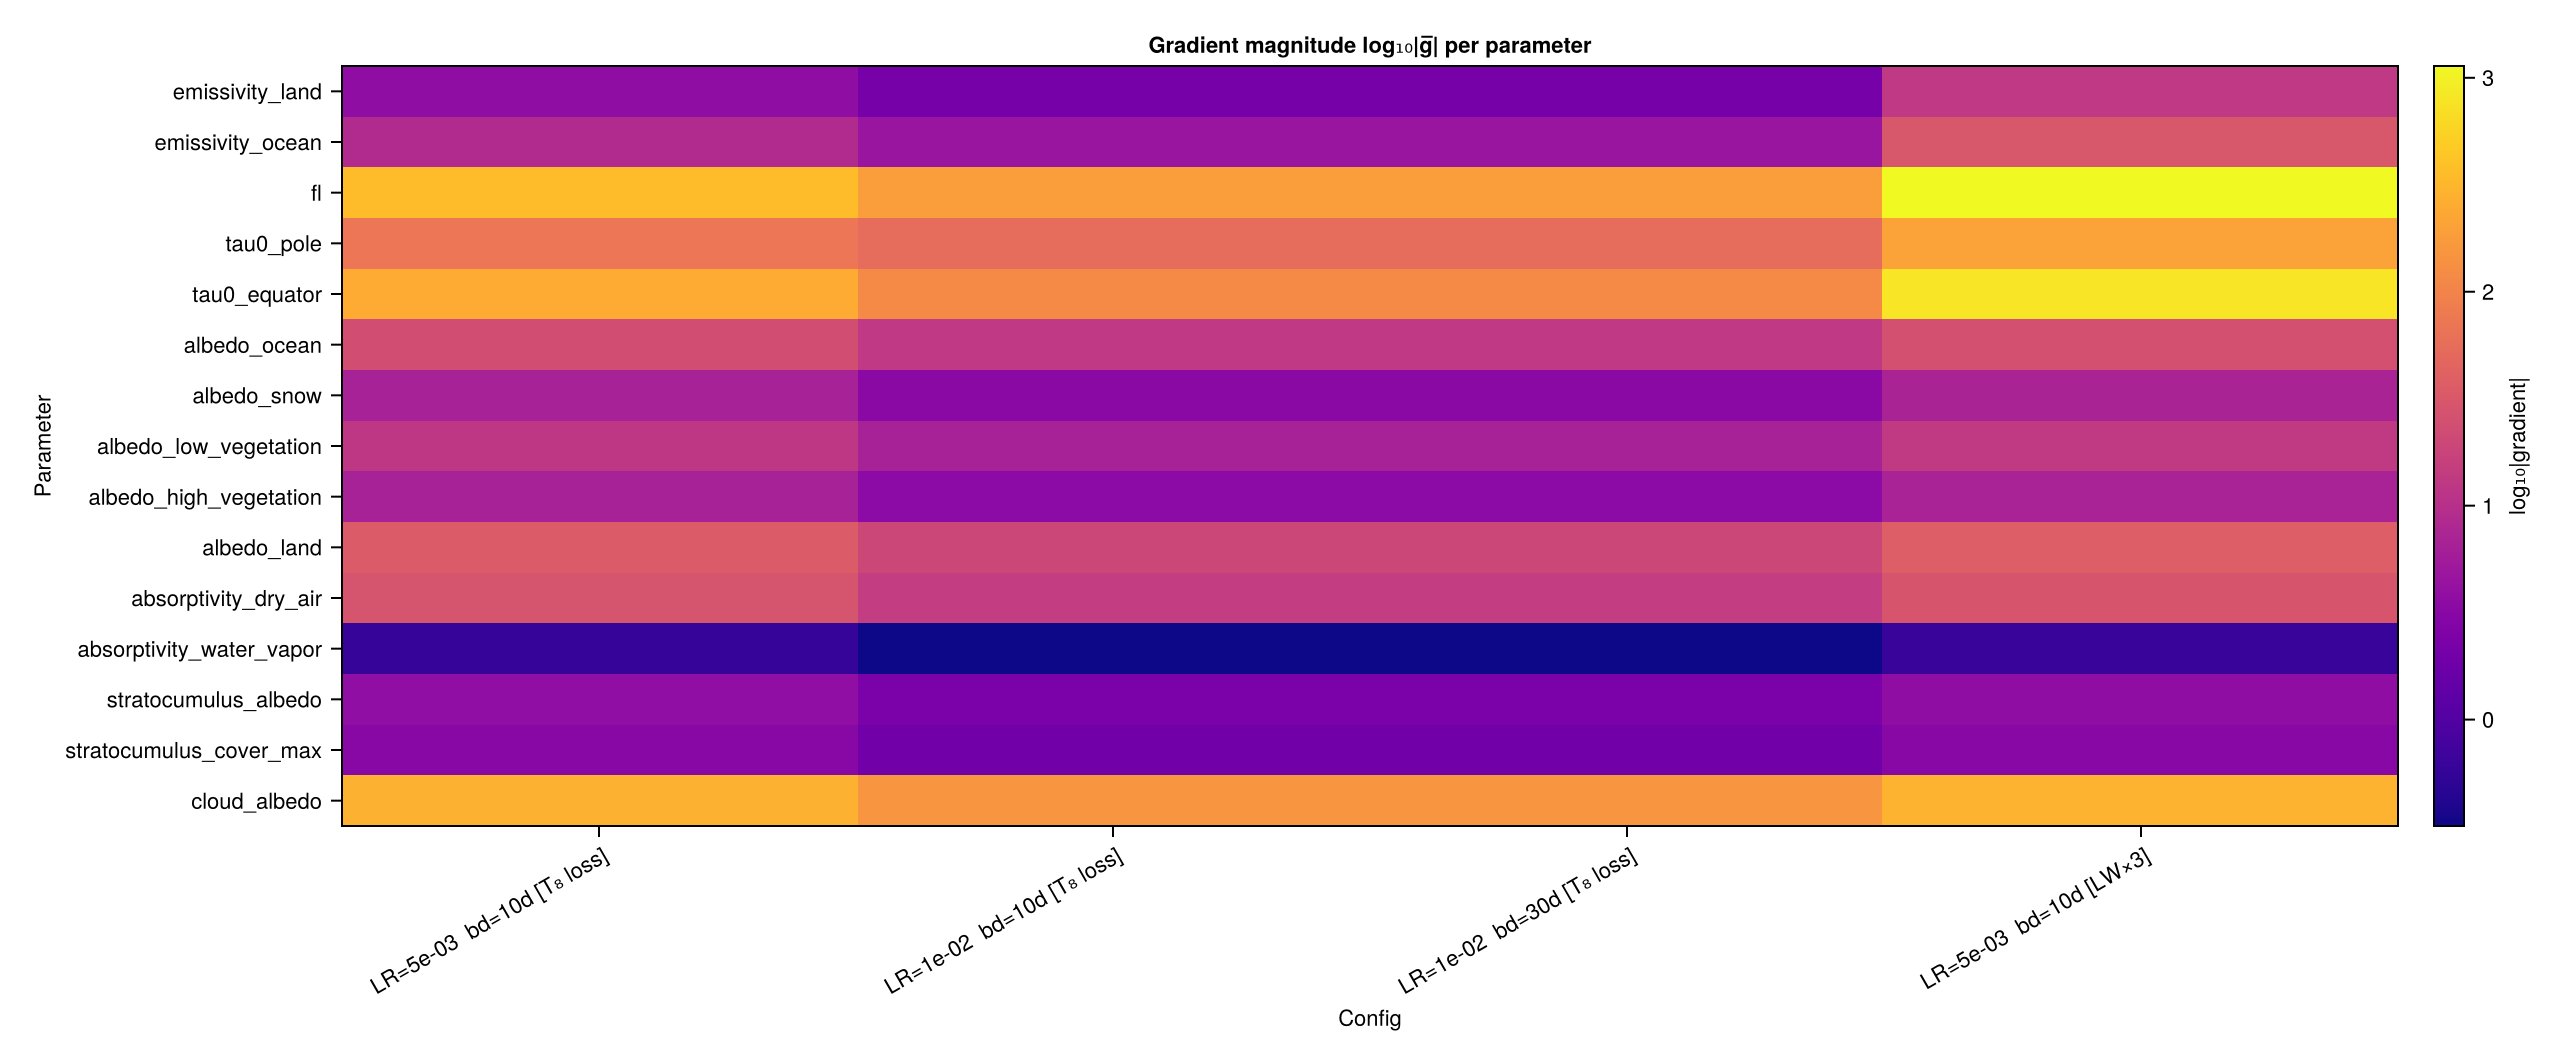

In [15]:
# Visual: gradient magnitude per parameter, per Phase-2 run
_param_names = [spec.name for spec in all_param_specs]
_np = length(_param_names)
_nr = length(phase2_runs)

_gmag = fill(NaN32, _np, _nr)
for (j, p2r) in enumerate(phase2_runs)
    r = get(phase2_results, p2r.name, nothing)
    isnothing(r) && continue
    nb = r.conv_info.total_batches
    for (i, spec) in enumerate(all_param_specs)
        gk = Symbol("grad_", spec.name)
        gv = get(r.history, gk, Float32[])
        isempty(gv) && continue
        _gmag[i, j] = log10(max(mean(abs.(gv[1:nb])), 1f-10))
    end
end

fig_grad = Figure(size=(800 + 120*_nr, 80 + 30*_np), fontsize=11)
ax_g = Axis(fig_grad[1,1];
    title  = "Gradient magnitude log₁₀|g̅| per parameter",
    xlabel = "Config",
    ylabel = "Parameter",
    xticks = (1:_nr, [p2r.label for p2r in phase2_runs]),
    yticks = (1:_np, string.(_param_names)),
    xticklabelrotation = π/6,
)
hm2 = heatmap!(ax_g, 1:_nr, 1:_np, permutedims(_gmag); colormap=:plasma)
Colorbar(fig_grad[1,2], hm2; label="log₁₀|gradient|", width=15)

save(joinpath(FULL_DIR, "gradient_heatmap.pdf"), fig_grad)
fig_grad

## 7  Summary and Next Steps

Run the cell below to print a compact winner summary.
Then proceed with the winning config for a full climate validation
via `run_climate_validation(result; n_years=7, stat_years=5)`.

**Common failure modes and fixes:**

| Symptom | Likely cause | Fix |
|---------|-------------|-----|
| Loss flat from batch 1 | LR too low or grad_clip too tight | Increase LR or `grad_clip` |
| Loss oscillates, no trend | LR too high | Reduce LR by 2× |
| NaN at batch 1 | Spinup too short or `batch_days` too long | Increase `spinup_days` |
| Only SW fluxes converge | LW gradient too weak | Add `grad_scale` to LW params or use `loss_lw_upweighted` |
| `param Δ ≈ 0` for LW params | LW path yields zero gradient | Check param path; may need higher `grad_scale` |

In [16]:
# Final winner summary
_best = argmin(
    p2r -> haskey(phase2_results, p2r.name) ?
           phase2_results[p2r.name].conv_info.best_smoothed_loss : Inf,
    phase2_runs)
r_win = phase2_results[_best.name]

println("="^60)
println("WINNER: ", _best.label)
println("="^60)
println("  Batches:    ", r_win.conv_info.total_batches)
@printf(  "  Best loss:  %.3f\n", r_win.conv_info.best_smoothed_loss)
println("  Stop:       ", r_win.conv_info.stop_reason)
println()
println("Final parameters:")
@printf("  %-28s  %8s  %8s  %+8s\n", "name", "initial", "trained", "change")
for spec in all_param_specs
    init    = isnothing(spec.initial) ? NaN32 : spec.initial
    trained = get(r_win.final_params, spec.name, NaN32)
    @printf("  %-28s  %8.4f  %8.4f  %+8.4f\n",
            spec.name, init, trained, trained - init)
end

println()
println("To run climate validation of this result:")
println("  clm = run_climate_validation(r_win; n_years=7, stat_years=5)")

WINNER: LR=1e-02  bd=10d [T₈ loss]
  Batches:    300
  Best loss:  126.443
  Stop:       max batches reached

Final parameters:
  name                           initial   trained    change
  cloud_albedo                    0.6000    0.7653   +0.1653
  stratocumulus_cover_max         0.6000    0.5309   -0.0691
  stratocumulus_albedo            0.5000    0.4265   -0.0735
  absorptivity_water_vapor       75.0000   61.3746  -13.6254
  absorptivity_dry_air            0.0314    0.0074   -0.0240
  albedo_land                     0.4000    0.5815   +0.1815
  albedo_high_vegetation          0.1500    0.2108   +0.0608
  albedo_low_vegetation           0.2000    0.2834   +0.0834
  albedo_snow                     0.4000    0.6375   +0.2375
  albedo_ocean                    0.0600    0.0782   +0.0182
  tau0_equator                    6.0000    7.3404   +1.3404
  tau0_pole                       1.5000    0.6216   -0.8784
  fl                              0.1000    0.4140   +0.3140
  emissivity_ocean

## 7  Multi-Seed Study

Run the best Phase-2 configuration from N different random initialisations
to quantify whether the optimised parameter vector is unique or one of many
compensating solutions.

**Scientific question:** Does the optimisation converge to a single physical
solution, or does the loss landscape contain multiple local minima?

Each seed initialises parameters by sampling uniformly within their bounds
rather than using the default `spec.initial` values.


In [17]:
using Random

const SEED_DIR  = joinpath(@__DIR__, "output", "hp_sweep_seeds")
const N_SEEDS   = 5   # increase to 10 for publication-quality uncertainty estimates

# Pick winner config from Phase 2 (auto-detected)
_winner_p2 = argmin(
    p2r -> haskey(phase2_results, p2r.name) ?
           phase2_results[p2r.name].conv_info.best_smoothed_loss : Inf,
    phase2_runs)

# Build param_specs with random initialisations (uniform within bounds)
function _random_init_specs(specs::Vector{ParamSpec}, rng::AbstractRNG)
    [ParamSpec(s.name, s.path;
               bounds    = s.bounds,
               initial   = s.bounds[1] + rand(rng, Float32) * (s.bounds[2] - s.bounds[1]),
               grad_scale = s.grad_scale)
     for s in specs]
end

seed_results = Dict{Int, TrainingResult}()

for seed in 1:N_SEEDS
    rfile = joinpath(SEED_DIR, "seed_$(seed)", "result.jld2")
    if isfile(rfile)
        seed_results[seed] = load_result(rfile)
        @printf("Seed %d  →  loaded from disk (best_loss=%.2f)\n",
                seed, seed_results[seed].conv_info.best_smoothed_loss)
        continue
    end
    @printf("\nSeed %d  →  starting...\n", seed)
    rng   = Random.MersenneTwister(seed)
    specs = _random_init_specs(all_param_specs, rng)
    r = calibrate!(
        specs,
        Optimisers.Adam(_winner_p2.base_config.lr),
        loss_trenberth,
        _full_cfg(_winner_p2);
        save_dir = joinpath(SEED_DIR, "seed_$(seed)"),
    )
    seed_results[seed] = r
    @printf("       done: best_loss=%.2f\n", r.conv_info.best_smoothed_loss)
end

println("\nMulti-seed summary:")
@printf("%-8s  %10s  %30s\n", "Seed", "Best loss", "Top-3 param changes")
println("-" ^ 60)
for seed in sort(collect(keys(seed_results)))
    r = seed_results[seed]
    top3 = sort(collect(r.final_params); by = kv -> abs(kv[2] - (findfirst(s -> s.name == kv[1], all_param_specs) !== nothing ? (isnothing(all_param_specs[findfirst(s -> s.name == kv[1], all_param_specs)].initial) ? NaN32 : all_param_specs[findfirst(s -> s.name == kv[1], all_param_specs)].initial) : NaN32)), rev=true)[1:min(3,end)]
    top3_str = join(["$(k)=$(round(v; digits=3))" for (k,v) in top3], ", ")
    @printf("%-8d  %10.2f  %s\n", seed, r.conv_info.best_smoothed_loss, top3_str)
end



Seed 1  →  starting...
SpeedyCalibration.jl — calibrate!
   1. cloud_albedo                     = 0.6336  [0.250, 0.950]  raw₀=0.193
   2. stratocumulus_cover_max          = 0.5529  [0.250, 0.950]  raw₀=-0.271
   3. stratocumulus_albedo             = 0.3235  [0.100, 0.900]  raw₀=-0.948
   4. absorptivity_water_vapor         = 74.9725  [60.000, 140.000]  raw₀=-1.469  [×0]
   5. absorptivity_dry_air             = 0.0435  [0.005, 0.060]  raw₀=0.846
   6. albedo_land                      = 0.1575  [0.100, 0.700]  raw₀=-2.244
   7. albedo_high_vegetation           = 0.1534  [0.040, 0.260]  raw₀=0.061
   8. albedo_low_vegetation            = 0.0908  [0.050, 0.350]  raw₀=-1.849
   9. albedo_snow                      = 0.5822  [0.150, 0.750]  raw₀=0.946
  10. albedo_ocean                     = 0.0389  [0.020, 0.100]  raw₀=-1.171
  11. tau0_equator                     = 2.9693  [2.000, 12.000]  raw₀=-2.232
  12. tau0_pole                        = 3.8932  [0.300, 4.000]  raw₀=3.516
  13. fl    

   0%  ETA: 3:45:07 (2000-09-16, 636.52 years/day, 106 m/s, [-107,   37] ˚C)

Spinup complete in 81.2 s.

Warming up Enzyme (compiling AD rules on actual model)...


   0%  ETA: 24.85 days (2000-09-17,  4.00 years/day, 106 m/s, [-106,   37] ˚C)

Enzyme warmup complete in 5498.9 s.
Starting training...
----------------------------------------------------------------------


...

Batch 130 | LR 5.0e-03 | osr= 31.3 sru= 17.8 srd=123.4 olr=309.9 lrd=366.9 lru=378.4 | L̄ 12191.83 | Δp 8.9e-04


   4%  ETA: 8:57:13 (2004-05-28, 256.82 years/day, 108 m/s, [-113,   59] ˚C)

Batch 135 | LR 5.0e-03 | osr= 30.9 sru= 17.9 srd=123.3 olr=309.9 lrd=368.2 lru=378.6 | L̄ 12167.28 | Δp 8.9e-04


   4%  ETA: 8:55:18 (2004-06-22, 257.56 years/day, 178 m/s, [-103,   59] ˚C)┌ Warning: NaN or Inf detected at time step 55955 (2004-06-22T08:00:00)
└ @ SpeedyWeather ~/master_thesis/SpeedyWeather.jl/SpeedyWeather/src/output/feedback.jl:123
   4%  ETA: 8:55:17 (2004-06-22, 257.56 years/day, NaN m/s, [ NaN,  NaN] ˚C)┌ Warning: NaN or Inf detected at time step 55962 (2004-06-22T12:40:00)
└ @ SpeedyWeather ~/master_thesis/SpeedyWeather.jl/SpeedyWeather/src/output/feedback.jl:123


Batch 139: all gradient samples invalid, stopping.

TRAINING SUMMARY
  cloud_albedo                     0.2528 → 0.2590
  stratocumulus_cover_max          0.6988 → 0.7874
  stratocumulus_albedo             0.3418 → 0.4587
  absorptivity_water_vapor         80.5388 → 67.5333
  absorptivity_dry_air             0.0530 → 0.0413
  albedo_land                      0.2976 → 0.4458
  albedo_high_vegetation           0.2394 → 0.2520
  albedo_low_vegetation            0.3331 → 0.3434
  albedo_snow                      0.3218 → 0.4908
  albedo_ocean                     0.0281 → 0.0402
  tau0_equator                     2.5914 → 3.6321
  tau0_pole                        2.0227 → 2.8923
  fl                               0.3023 → 0.4080
  emissivity_ocean                 0.8105 → 0.8276
  emissivity_land                  0.9125 → 0.9531
----------------------------------------------------------------------
  Final osr :  31.19 W/m²  (target: 101.9)
  Final sru :  18.04 W/m²  (target: 23.0)
  Final 

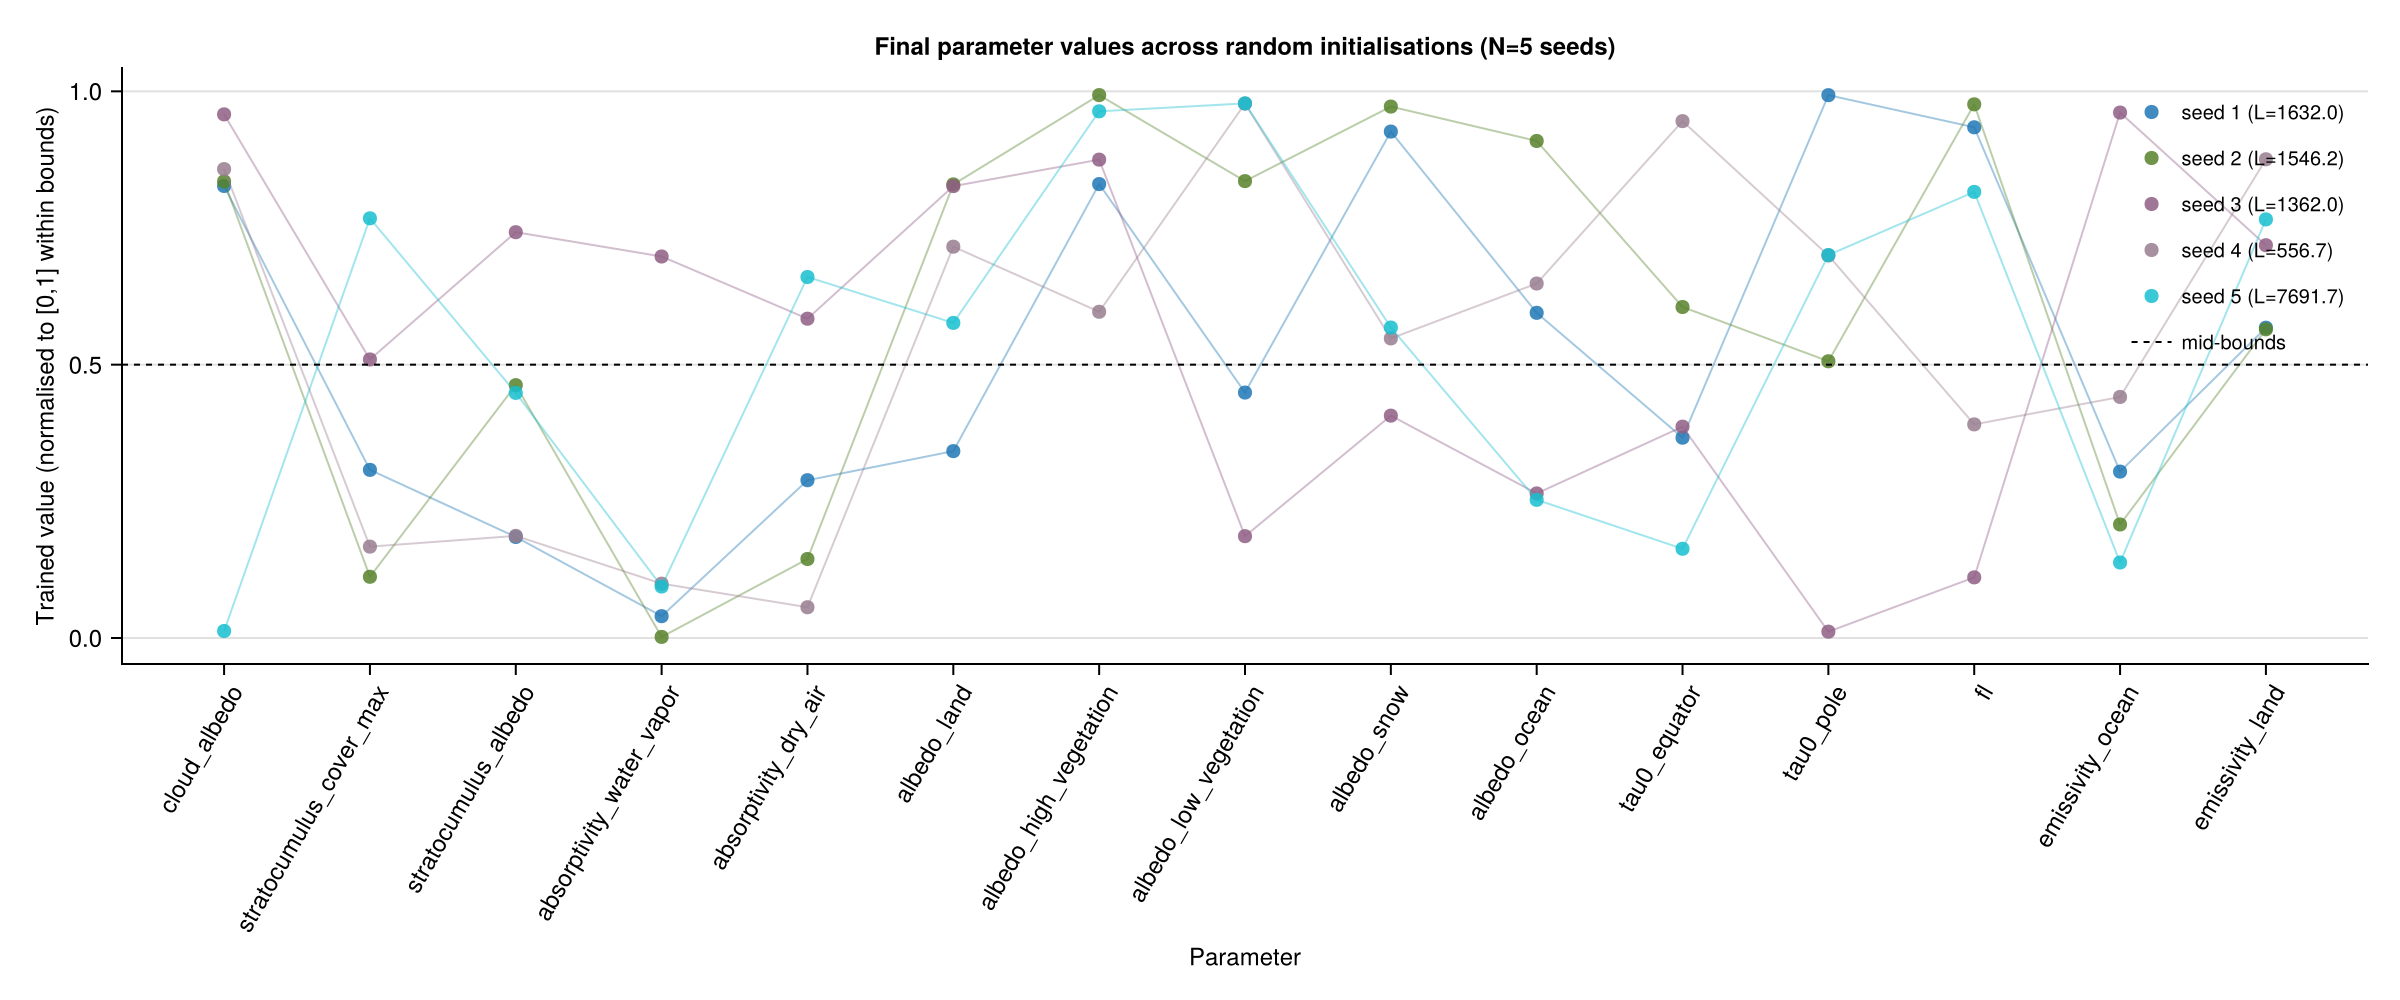

In [18]:
# Compare final parameter values across seeds
fig_seeds = Figure(size=(1200, 500), fontsize=12)
_seed_ids = sort(collect(keys(seed_results)))
_param_names_all = [spec.name for spec in all_param_specs]

ax_s = Axis(fig_seeds[1,1];
    title  = "Final parameter values across random initialisations (N=$(N_SEEDS) seeds)",
    xlabel = "Parameter",
    ylabel = "Trained value (normalised to [0,1] within bounds)",
    xticks = (1:length(_param_names_all), string.(_param_names_all)),
    xticklabelrotation = π/3,
    xgridvisible=false, ygridvisible=true,
    topspinevisible=false, rightspinevisible=false,
)

_seed_colors = cgrad(:tab10, N_SEEDS; categorical=true)
for (j, seed) in enumerate(_seed_ids)
    r = seed_results[seed]
    ys = Float32[
        let spec = all_param_specs[i]
            v = get(r.final_params, spec.name, NaN32)
            (v - spec.bounds[1]) / (spec.bounds[2] - spec.bounds[1])
        end
        for i in 1:length(all_param_specs)
    ]
    scatter!(ax_s, 1:length(ys), ys;
             color=(_seed_colors[j], 0.85), markersize=10,
             label="seed $(seed) (L=$(round(r.conv_info.best_smoothed_loss; digits=1)))")
    lines!(ax_s, 1:length(ys), ys; color=(_seed_colors[j], 0.4), linewidth=1)
end
hlines!(ax_s, [0.5f0]; color=:black, linestyle=:dash, linewidth=1, label="mid-bounds")
axislegend(ax_s; position=:rt, framevisible=false, labelsize=10)

save(joinpath(SEED_DIR, "seed_comparison.pdf"), fig_seeds)
fig_seeds
